### 샘플데이터 생성

In [53]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
%matplotlib inline

weights = np.array([0.32, 0.48, 0.2])
t_means = np.array([[-1, 2.5], [1, 4.3], [3, 6.5]])
t_covs = np.zeros((3, 2, 2))

t_covs[0] = np.array([[0.8, 0.1], [0.1, 0.8]]) / 3
t_covs[1] = np.array([[0.6, 0.3], [0.3, 0.6]]) / 3
t_covs[2] = np.array([[0.7, 0.1], [0.1, 0.7]]) / 3

col = ['red', 'green', 'blue', 'black', 'cyan']

# 생성될 샘플 크기
N = 100
n_samples = np.zeros((N, 2))

for i in range(N):
    z = np.random.random()
    idx = 0
    needle = 0

    for j in range(len(weights)):
        if z >= needle and z <= needle + weights[j]:
            idx = j
            break
        else:
            needle += weights[j]

    # 다변량정규분포 100개의 샘플 데이터 생성
    n_samples[i] = np.random.multivariate_normal(
        t_means[idx],
        t_covs[idx]
    )

### 파라미터 초기화

In [54]:
showChart = [1, 2, 10, 20, 40, 60, 99]
k = 3
Step = 100

means = np.zeros((Step, k, 2))
cov = np.zeros((Step, k, 2, 2))
weights = np.zeros((Step, k))
likelihood = np.zeros(Step - 1)
assignment = np.zeros((N, k))

init_idx = np.random.choice(N, k, replace=False)

for i in range(k):
    means[0, i] = n_samples[init_idx[i]]
    cov[0, i] = np.eye(2)
    weights[0, i] = 1.0 / k

### EM

$$# | 변수                 | 의미                                        
# | `N`                  | 데이터 개수                                           
# | `k`                   | Gaussian component 개수                            
# | `Step`             | EM 반복 횟수                                         
# | `n_samples[i]`     | i번째 2차원 데이터                                      
# | `means[l, j]`         | l번째 iteration에서 j번째 Gaussian 평균                  
# | `cov[l, j]`               | l번째 iteration에서 j번째 Gaussian 공분산                 
# | `weights[l, j]`       | l번째 iteration에서 j번째 component의 mixing weight     
# | `assignment[i, j]` | i번째 데이터가 j번째 component에 속할 posterior probability
$$

In [56]:
for l in range(1, Step):

    # E-step
    for j in range(N):
        for i in range(k):
            assignment[j, i] = weights[l-1, i] * multivariate_normal.pdf(
                n_samples[j],
                means[l-1, i],
                cov[l-1, i] + 1e-6 * np.eye(2),
                allow_singular=True
            )

        denom = np.sum(assignment[j])

        if denom < 1e-6:
            assignment[j] = np.ones(k) / k
        else:
            assignment[j] /= denom


    # M-step: means update
    for j in range(k):
        normalize = 0
        means[l, j] = np.zeros(2)

        for i in range(N):
            means[l, j] += assignment[i, j] * n_samples[i]
            normalize += assignment[i, j]

        if normalize < 1e-6:
            means[l, j] = means[l-1, j]
        else:
            means[l, j] /= normalize


    # M-step: covariance update
    for j in range(k):
        normalize = 0
        cov[l, j] = np.zeros((2, 2))

        for i in range(N):
            diff = n_samples[i] - means[l, j]
            cov[l, j] += assignment[i, j] * np.outer(diff, diff)
            normalize += assignment[i, j]

        if normalize < 1e-6:
            cov[l, j] = cov[l-1, j]
        else:
            cov[l, j] /= normalize

        cov[l, j] += 1e-6 * np.eye(2)


    # M-step: weights update
    for j in range(k):
        weights[l, j] = np.sum(assignment[:, j]) / N

    weights[l] /= np.sum(weights[l])

In [57]:
    ## log likelihood 계산
    likelihood[l-1] = 0

    for j in range(N):
        sum_LH = 0

        for i in range(k):
            cov_reg = cov[l, i] + eps * np.eye(2)

            sum_LH += weights[l, i] * multivariate_normal.pdf(
                n_samples[j],
                means[l, i],
                cov_reg,
                allow_singular=True
            )

        likelihood[l-1] += np.log(sum_LH + eps)

In [58]:
from matplotlib.patches import Ellipse

def draw_ellipse(mean, cov_matrix, ax, color):
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)

    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    # 1, 2, 3-sigma ellipse
    for scale in [1, 2, 3]:
        width, height = 2 * scale * np.sqrt(eigvals)

        ellipse = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            edgecolor=color,
            facecolor='none',
            linewidth=2,
            alpha=0.5
        )

        ax.add_patch(ellipse)

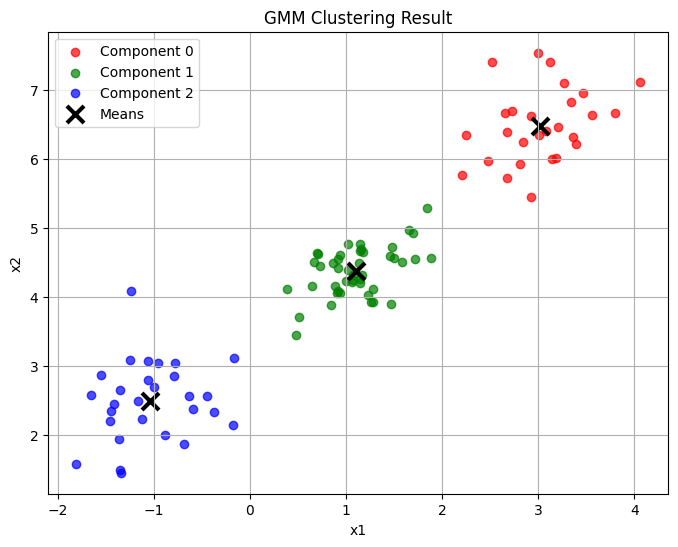

In [59]:
# 마지막 iteration 결과 사용
last = Step - 1

# 각 데이터가 가장 높은 확률로 속한 component
labels = np.argmax(assignment, axis=1)

plt.figure(figsize=(8, 6))

for i in range(k):
    plt.scatter(
        n_samples[labels == i, 0],
        n_samples[labels == i, 1],
        c=col[i],
        label=f'Component {i}',
        alpha=0.7
    )

# component 평균 표시
plt.scatter(
    means[last, :, 0],
    means[last, :, 1],
    c='black',
    marker='x',
    s=150,
    linewidths=3,
    label='Means'
)

plt.title('GMM Clustering Result')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
print("n_samples shape:", n_samples.shape)
print("means shape:", means.shape)
print("cov shape:", cov.shape)
print("weights shape:", weights.shape)

n_samples shape: (100, 2)
means shape: (100, 3, 2)
cov shape: (100, 3, 2, 2)
weights shape: (100, 3)


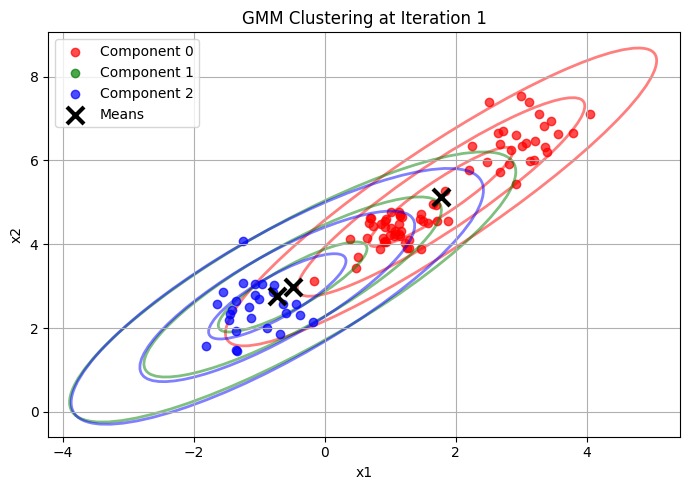

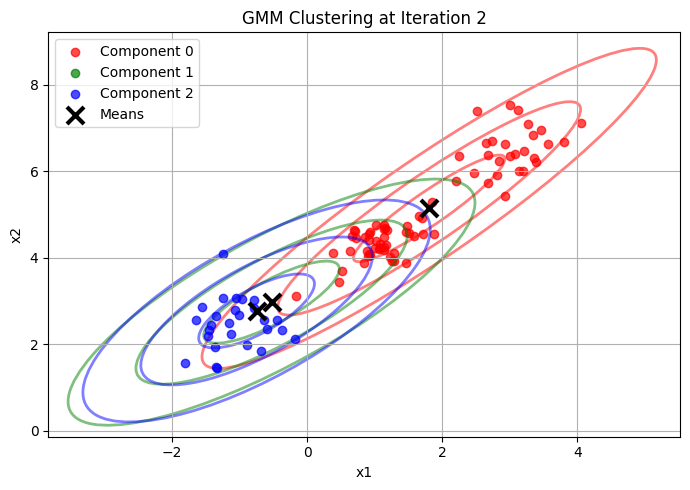

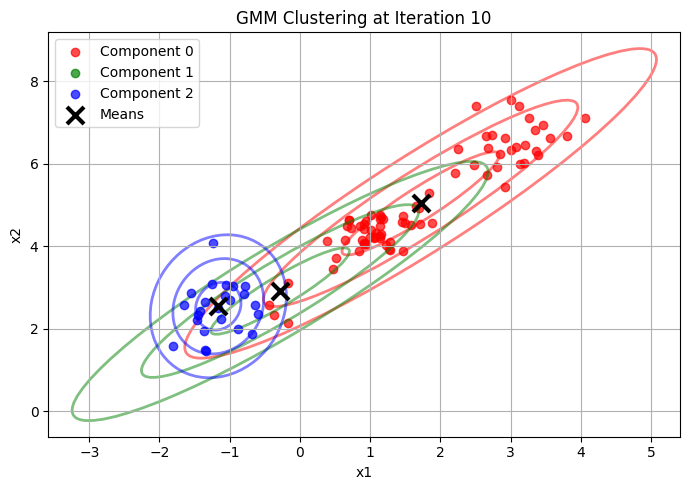

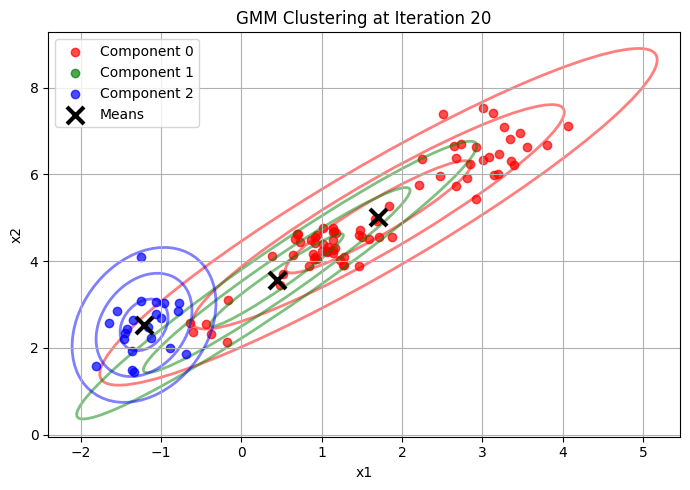

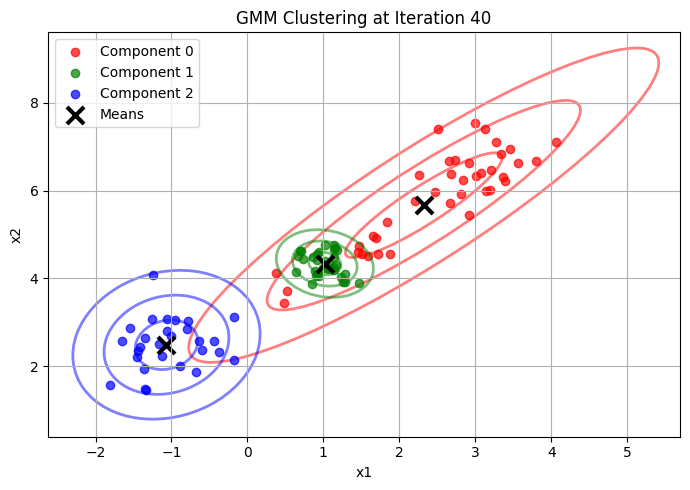

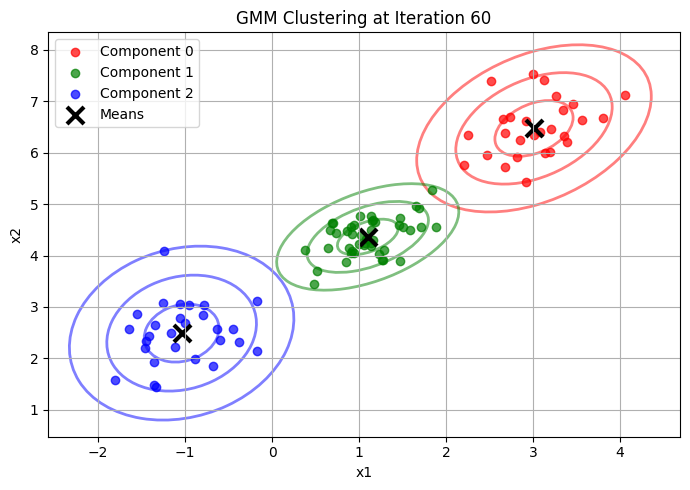

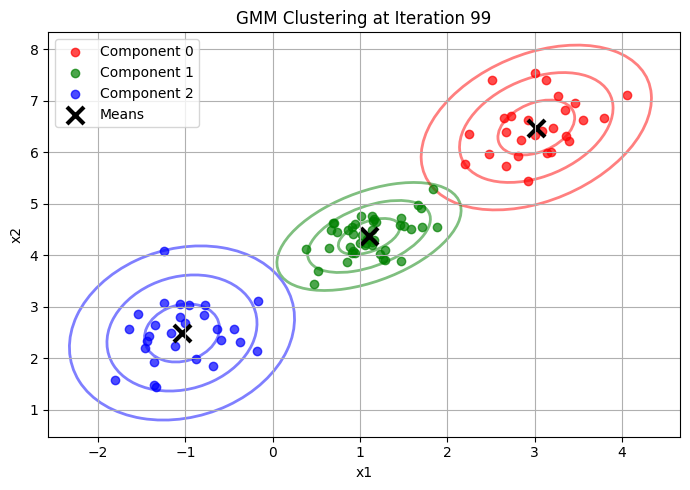

In [61]:
eps = 1e-6
N, dim = n_samples.shape

for step in showChart:
    probs = np.zeros((N, k))

    for i in range(k):
        cov_i = cov[step, i] + eps * np.eye(dim)

        if weights.ndim == 1:
            weight_i = weights[i]
        else:
            weight_i = weights[step, i]

        probs[:, i] = weight_i * multivariate_normal.pdf(
            n_samples,
            mean=means[step, i],
            cov=cov_i,
            allow_singular=True
        )

    labels = np.argmax(probs, axis=1)

    fig, ax = plt.subplots(figsize=(7, 5))

    for i in range(k):
        mask = labels == i

        ax.scatter(
            n_samples[mask, 0],
            n_samples[mask, 1],
            color=col[i % len(col)],
            label=f'Component {i}',
            alpha=0.7
        )

        draw_ellipse(
            means[step, i],
            cov[step, i] + eps * np.eye(dim),
            ax,
            col[i % len(col)]
        )

    ax.scatter(
        means[step, :, 0],
        means[step, :, 1],
        color='black',
        marker='x',
        s=150,
        linewidths=3,
        label='Means'
    )

    ax.set_title(f'GMM Clustering at Iteration {step}')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

In [62]:
print("n_samples shape:", n_samples.shape)
print("means shape:", means.shape)
print("cov shape:", cov.shape)
print("weights shape:", weights.shape)
print("labels shape:", labels.shape)

n_samples shape: (100, 2)
means shape: (100, 3, 2)
cov shape: (100, 3, 2, 2)
weights shape: (100, 3)
labels shape: (100,)
